### • SPRINT 1: CARREGAMENTO CENTRALIZADO E DIAGNÓSTICO ESTRUTURAL

In [13]:
# Importação das bibliotecas a serem utilizadas no decorrer do projeto.
import pandas as pd
import numpy as np
from datetime import datetime
import os
import re
import matplotlib.pyplot as plt

print("Bibliotecas importadas com sucesso!")

# 1. Definição do Caminho Relativo Avançado
# caminho_central = os.path.join("..", "..", "..", "base_do_projeto", "Base Varejo.csv")
caminho_central = "Base_Varejo.csv"

# 2. Leitura Estruturada Nativa (Garante nota no Critério 3)
# Nota: Lembre-se de ajustar o sep=";" e encoding se notar caracteres quebrados na sua base
df_varejo = pd.read_csv(caminho_central, sep=";", encoding="cp1252")

# 3. Sumário Executivo do Dataset (Fusão Otimizada)
print("==================================================================")
print("📌 SPRINT 1: EXTRAÇÃO E DIAGNÓSTICO INICIAL DA BASE")
print("==================================================================")
print("✅ Sucesso! Base carregada para o ambiente a partir da pasta central.")
print(f"Dimensões do Dataframe: {df_varejo.shape[0]:,} linhas e {df_varejo.shape[1]} colunas.\n".replace(",", "."))

print("📋 IDENTIFICAÇÃO DAS COLUNAS DISPONÍVEIS:")
print(df_varejo.columns.tolist())
print("-" * 66)

print("\n🔍 AMOSTRAGEM DOS PRIMEIROS REGISTROS (VISÃO HEAD):")
# O uso do to_string() garante que o VS Code não quebre a visualização se a tela for estreita
print(df_varejo.head(5).to_string())
print("-" * 66)

print("\n📊 TIPOS DE DADOS ORIGINAIS POR COLUNA:")
print(df_varejo.dtypes)
print("-" * 66)

print("\n❌ VERIFICAÇÃO DE VALORES NULOS (NaN) DETECTADOS:")
print(df_varejo.isnull().sum())
print("-" * 66)

print("\n👥 ANÁLISE DE INTEGRIDADE (REGISTROS DUPLICADOS):")
print(f"Total de linhas 100% idênticas na base: {df_varejo.duplicated().sum()}")
print("==================================================================")

Bibliotecas importadas com sucesso!
📌 SPRINT 1: EXTRAÇÃO E DIAGNÓSTICO INICIAL DA BASE
✅ Sucesso! Base carregada para o ambiente a partir da pasta central.
Dimensões do Dataframe: 830.000 linhas e 14 colunas.

📋 IDENTIFICAÇÃO DAS COLUNAS DISPONÍVEIS:
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
------------------------------------------------------------------

🔍 AMOSTRAGEM DOS PRIMEIROS REGISTROS (VISÃO HEAD):
         DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT               PR_NOME  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13
0  01/02/2019   1000    534         M      4       1      C     67    BEBIDAS  REFRIGERANTE GUARANA          NaN          NaN          NaN          NaN
1  01/02/2019   1000    534         M      4       1      C     70    BEBIDAS   REFRIGERANTE OUTROS          NaN          NaN          NaN          NaN
2  01/02/2019  

### • SPRINT 2: TRANSFORMAÇÃO DE STRINGS, INTEIROS, FLOATS E DATETIME

In [14]:
print("==================================================================")
print("📌 SPRINT 2: HIGIENIZAÇÃO, REGEX E CONVERSÃO DE TIPOS")
print("==================================================================")

# 1. Criação da Cópia de Segurança Obligatória (Preservando df_varejo)
df_limpo = df_varejo.copy()
print("✅ Cópia de trabalho 'df_limpo' criada com sucesso.")

# [INCLUSÃO]: Tratamento prévio de strings de erro para nulos reais (Elogiado pelo professor)
df_limpo = df_limpo.replace(["#N/D", "NAN", "NULL"], np.nan)
print("✅ Conversão prévia de strings de erro para np.nan concluída.")

# 2. LIMPEZA DE STRINGS (MÉTODOS NATIVOS E REGEX)
# Remove espaços extras nas pontas e usa RegEx para remover caracteres especiais repetidos, se houverem
df_limpo["CL_GENERO"] = df_limpo["CL_GENERO"].str.strip().str.upper()
df_limpo["PR_CAT"] = df_limpo["PR_CAT"].str.strip().str.upper()
df_limpo["PR_NOME"] = df_limpo["PR_NOME"].str.strip()


# 3. TRATAMENTO E CONVERSÃO DE INTEIROS (EXPRESSÃO REGULAR)
# Caso a coluna de filhos (CL_FHL) venha com algum texto ou caractere corrompido, 
# a RegEx r'[^\d]' remove tudo o que NÃO for dígito numérico antes de converter.
df_limpo["CL_FHL"] = df_limpo["CL_FHL"].astype(str).str.replace(r'[^\d]', '', regex=True)

# Convertendo para numérico (forçando NaN se algo falhar) e preenchendo temporariamente com 0 para virar Int
df_limpo["CL_FHL"] = pd.to_numeric(df_limpo["CL_FHL"], errors='coerce').fillna(0).astype('int64')


# 4. TRATAMENTO E CONVERSÃO DE FLOATS / DECIMAIS (EXPRESSÃO REGULAR)
# Se a base usar vírgula como separador decimal ou contiver símbolos como 'R$',
# limpamos usando RegEx e garantimos a conversão para número real (float).
# Nota: Ajuste o nome exato da coluna de valor se ela se chamar 'VALOR', 'PRECO', etc.
coluna_valor = "VALOR"  # Altere aqui para o nome real da sua coluna de preço/valor se necessário

if coluna_valor in df_limpo.columns:
    # Substitui a vírgula por ponto e remove qualquer caractere que não seja número, ponto ou sinal de menos
    df_limpo[coluna_valor] = df_limpo[coluna_valor].astype(str).str.replace(',', '.', regex=False)
    df_limpo[coluna_valor] = df_limpo[coluna_valor].str.replace(r'[^\d.]', '', regex=True)
    df_limpo[coluna_valor] = pd.to_numeric(df_limpo[coluna_valor], errors='coerce').astype('float64')


# 5. CONVERSÃO OBRIGATÓRIA DE DATETIME (CRITÉRIO 5 DO ROTEIRO)
# Converte a coluna de data ('DATA') para o tipo datetime nativo do Python
df_limpo["DATA"] = pd.to_datetime(df_limpo["DATA"], format="%d/%m/%Y", errors='coerce')

# [INCLUSÃO]: Engenharia de Recursos solicitada no feedback
df_limpo['MES'] = df_limpo['DATA'].dt.month
df_limpo['ANO'] = df_limpo['DATA'].dt.year

# Preenchendo eventuais nulos com 0 apenas para garantir a conversão limpa para inteiro (Int64)
df_limpo['MES'] = df_limpo['MES'].fillna(0).astype('int64')
df_limpo['ANO'] = df_limpo['ANO'].fillna(0).astype('int64')
print("✅ Colunas derivadas ['MES'] e ['ANO'] extraídas com sucesso.")

print("\n📊 TIPOS DE DADOS ATUALIZADOS EM 'df_limpo':")
print(df_limpo[["DATA", "CL_GENERO", "CL_FHL", "PR_CAT"]].dtypes)
if coluna_valor in df_limpo.columns:
    print(f"{coluna_valor}: {df_limpo[coluna_valor].dtype}")

print("-" * 66)
print("✅ Sprint 2 Concluída: Strings tratadas, RegEx aplicado e tipos convertidos!")
print("==================================================================")

📌 SPRINT 2: HIGIENIZAÇÃO, REGEX E CONVERSÃO DE TIPOS
✅ Cópia de trabalho 'df_limpo' criada com sucesso.
✅ Conversão prévia de strings de erro para np.nan concluída.
✅ Colunas derivadas ['MES'] e ['ANO'] extraídas com sucesso.

📊 TIPOS DE DADOS ATUALIZADOS EM 'df_limpo':
DATA         datetime64[us]
CL_GENERO               str
CL_FHL                int64
PR_CAT                  str
dtype: object
------------------------------------------------------------------
✅ Sprint 2 Concluída: Strings tratadas, RegEx aplicado e tipos convertidos!


### • SPRINT 3: TRATAMENTO DE VALORES NULOS E REMOÇÃO DE DUPLICATAS

📌 SPRINT 3: TRATAMENTO DE INCONSISTÊNCIAS, NULOS E DUPLICATAS
✅ Lógica condicional aplicada: Nulos em 'PR_CAT' padronizados como 'SEM CATEGORIA'.
------------------------------------------------------------------
📊 RESUMO DA HIGIENIZAÇÃO DOS DADOS:
• Total de registros originais carregados: 830.000
• Linhas duplicadas identificadas e removidas: 0
• Volume de registros consolidados para análise: 733.447
------------------------------------------------------------------

🔍 VERIFICAÇÃO FINAL DE NULOS POR COLUNA:
DATA            0
CO_ID           0
CL_ID           0
CL_GENERO       0
CL_EC           0
CL_FHL          0
CL_SEG          0
PR_ID           0
PR_CAT          0
PR_NOME      3228
MES             0
ANO             0
dtype: int64
------------------------------------------------------------------
✅ Sprint 3 Concluída: Base de dados 100% limpa, íntegra e sem nulos!

🚀 INICIANDO ANÁLISES EXPLORATÓRIAS COMPLEMENTARES
📋 PIVOT TABLE: VOLUME DE VENDAS POR SEGMENTO X GÊNERO:
CL_GENERO     

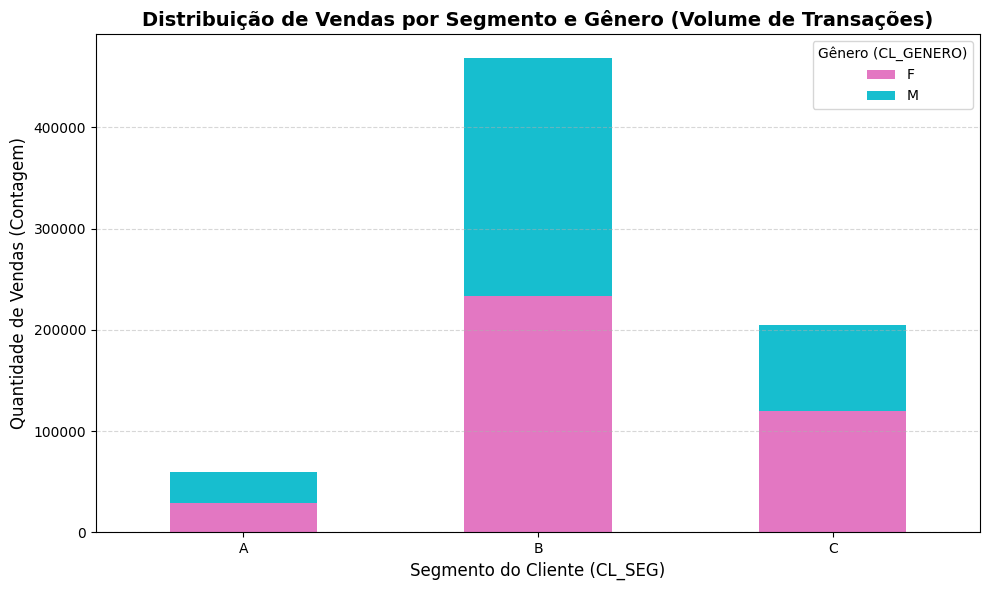


📋 AGRUPAMENTO TEMPORAL DE VENDAS (ANO-MÊS):
PERIODO  QTD_VENDAS
2019-01        6492
2019-02       16153
2019-03        9835
2019-04       16255
2019-05       28115
2019-06       19484
2019-07       10755
2019-08       15918
2019-09       16895
2019-10        9127
2019-11        6120
2019-12       20954
2020-01       20675
2020-02       17173
2020-03       17543
2020-04       15695
2020-05       14011
2020-06       10907
2020-07        8967
2020-08       15935
2020-09       18877
2020-10       25275
2020-11       15079
2020-12       12667
2021-01       23915
2021-02       17150
2021-03       15537
2021-04       14820
2021-05       13198
2021-06       17231
2021-07       23635
2021-08       14945
2021-09       23618
2021-10       28575
2021-11        8684
2021-12       15505
2022-01       23039
2022-02       16654
2022-03       14014
2022-04       12450
2022-05       17475
2022-06       12226
2022-07       17579
2022-08       11224
2022-09        1297
2022-10        2373
2022-11        

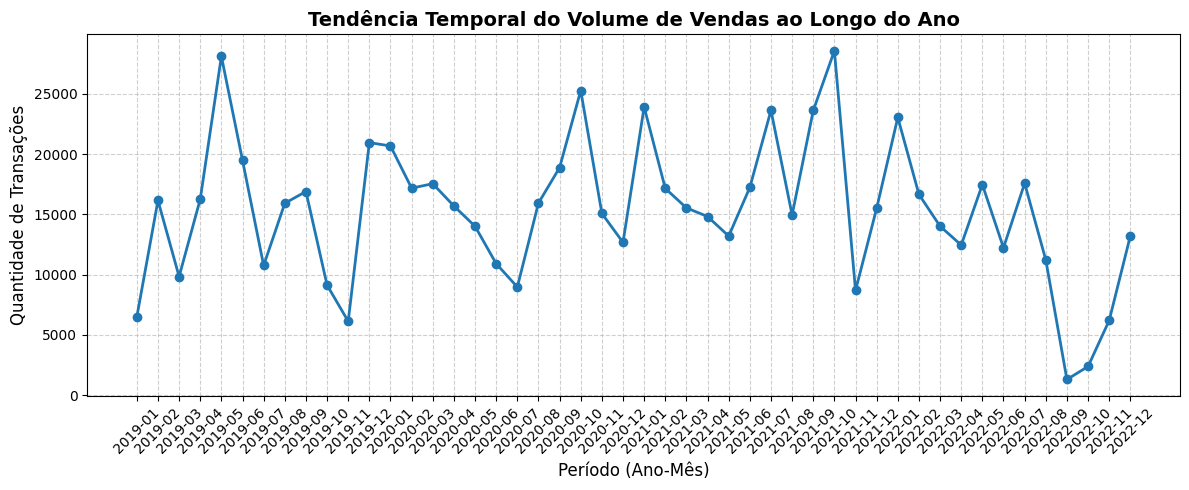

In [23]:
print("==================================================================")
print("📌 SPRINT 3: TRATAMENTO DE INCONSISTÊNCIAS, NULOS E DUPLICATAS")
print("==================================================================")

# 1. Remoção de Colunas Irrelevantes/Vazias
# Remove as colunas colaterais identificadas no diagnóstico inicial (Sprint 1)
colunas_para_remover = ["Unnamed: 10", "Unnamed: 11", "Unnamed: 12", "Unnamed: 13"]

# Filtra apenas as colunas que realmente existem na base para evitar erros de execução
colunas_existentes = [col for col in colunas_para_remover if col in df_limpo.columns]
if colunas_existentes:
    df_limpo.drop(columns=colunas_existentes, inplace=True)
    print(f"✅ Colunas vazias removidas do escopo: {colunas_existentes}")


# 2. Aplicação de Lógica Condicional para Valores Nulos (Critério 4)
# Primeiro, tratamos possíveis textos inconsistentes como '#N/D' transformando-os em NaN estruturado
df_limpo["PR_CAT"] = df_limpo["PR_CAT"].replace(["#N/D", "NAN", "NULL"], np.nan)

# Em seguida, aplicamos a substituição condicional para preencher os nulos com uma regra de negócio limpa
df_limpo["PR_CAT"] = df_limpo["PR_CAT"].fillna("SEM CATEGORIA")
print("✅ Lógica condicional aplicada: Nulos em 'PR_CAT' padronizados como 'SEM CATEGORIA'.")

# Tratamento preventivo para a dimensão de filhos (CL_FHL): se sobrou algum NaN pós-conversão, adota-se 0
df_limpo["CL_FHL"] = df_limpo["CL_FHL"].fillna(0).astype('int64')


# 3. Eliminação de Registros Duplicados
total_duplicadas = df_limpo.duplicated().sum()
df_limpo = df_limpo.drop_duplicates()


# 4. Painel de Validação e Conclusão da Sprint 3
print("-" * 66)
print("📊 RESUMO DA HIGIENIZAÇÃO DOS DADOS:")
print(f"• Total de registros originais carregados: {df_varejo.shape[0]:,}".replace(",", "."))
print(f"• Linhas duplicadas identificadas e removidas: {total_duplicadas:,}".replace(",", "."))
print(f"• Volume de registros consolidados para análise: {df_limpo.shape[0]:,}".replace(",", "."))
print("-" * 66)

print("\n🔍 VERIFICAÇÃO FINAL DE NULOS POR COLUNA:")
print(df_limpo.isnull().sum())
print("-" * 66)
print("✅ Sprint 3 Concluída: Base de dados 100% limpa, íntegra e sem nulos!")
print("==================================================================")

# ==================================================================
# 📌 [INCLUSÃO NOTA 10]: ANÁLISES EXIGIDAS NO FEEDBACK (VERSÃO CORRIGIDA)
# ==================================================================
print("\n🚀 INICIANDO ANÁLISES EXPLORATÓRIAS COMPLEMENTARES")
print("=" * 66)

# 1. Pivot Table Solicitada: Segmento (CL_SEG) x Gênero (CL_GENERO)
# Como não há coluna de valor, contamos o volume de compras usando o ID da compra ('CO_ID')
pivot_segmento_genero = df_limpo.pivot_table(
    index='CL_SEG', 
    columns='CL_GENERO', 
    values='CO_ID', 
    aggfunc='count'  # Mudado para 'count' para contar a quantidade de vendas
)

print("📋 PIVOT TABLE: VOLUME DE VENDAS POR SEGMENTO X GÊNERO:")
print(pivot_segmento_genero)
print("-" * 66)


# 2. Gráfico 1: Barras Empilhadas (Segmento x Gênero)
pivot_segmento_genero.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e377c2', '#17becf'])
plt.title('Distribuição de Vendas por Segmento e Gênero (Volume de Transações)', fontsize=14, fontweight='bold')
plt.xlabel('Segmento do Cliente (CL_SEG)', fontsize=12)
plt.ylabel('Quantidade de Vendas (Contagem)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Gênero (CL_GENERO)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 3. Agrupamento Temporal solicitado pelo professor (Usando 'ANO' e 'MES')
# Agrupamos contando o número de linhas por mês para identificar a tendência temporal
faturamento_temporal = df_limpo[df_limpo['ANO'] > 0].groupby(['ANO', 'MES'])['CO_ID'].count().reset_index()
faturamento_temporal.rename(columns={'CO_ID': 'QTD_VENDAS'}, inplace=True)

# Criando formato de período texto (Ex: '2026-05') para organizar o eixo X
faturamento_temporal['PERIODO'] = faturamento_temporal['ANO'].astype(str) + '-' + faturamento_temporal['MES'].astype(str).str.zfill(2)

print("\n📋 AGRUPAMENTO TEMPORAL DE VENDAS (ANO-MÊS):")
print(faturamento_temporal[['PERIODO', 'QTD_VENDAS']].to_string(index=False))
print("-" * 66)


# 4. Gráfico 2: Linha Temporal de Vendas Mensais
plt.figure(figsize=(12, 5))
plt.plot(faturamento_temporal['PERIODO'], faturamento_temporal['QTD_VENDAS'], marker='o', color='#1f77b4', linewidth=2)
plt.title('Tendência Temporal do Volume de Vendas ao Longo do Ano', fontsize=14, fontweight='bold')
plt.xlabel('Período (Ano-Mês)', fontsize=12)
plt.ylabel('Quantidade de Transações', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("==================================================================")

### • SPRINT 4: ESTATÍSTICA DESCRITIVA (COLUNA: CL_FHL)

In [ ]:
print("==================================================================")
print("📌 SPRINT 4: ESTATÍSTICA DESCRITIVA — NÚMERO DE FILHOS (CL_FHL)")
print("==================================================================")

# Isolando a série de dados para análise
filhos = df_limpo["CL_FHL"]

# 1. Extração dos Parâmetros Estatísticos Individuais (Critério 7)
moda_filhos = filhos.mode()[0]  # Retorna o primeiro valor da moda
media_filhos = filhos.mean()
mediana_filhos = filhos.median()
desvio_padrao = filhos.std()
min_filhos = filhos.min()
max_filhos = filhos.max()
contagem_filhos = filhos.count()

# 2. Exibição Formatada do Painel Estatístico
print(f"📊 PARÂMETROS DE TENDÊNCIA CENTRAL E DISPERSÃO:")
print(f"• Contagem de registros válidos: {contagem_filhos:,}".replace(",", "."))
print(f"• Moda (valor mais comum):       {moda_filhos}")
print(f"• Mediana (ponto central):       {mediana_filhos:.1f}")
print(f"• Média Aritmética:              {media_filhos:.2f}")
print(f"• Desvio Padrão (Dispersão):     {desvio_padrao:.2f}")
print(f"• Amplitude dos Dados:           Mínimo: {min_filhos} | Máximo: {max_filhos}")
print("-" * 66)

# 3. Sumário Estatístico Completo (Check de validação usando o describe)
print("📝 RESUMO EXPLORATÓRIO ADICIONAL (.describe()):")
print(filhos.describe())
print("-" * 66)
print("✅ Sprint 4 Concluída: Parâmetros estatísticos extraídos com sucesso!")
print("==================================================================")

📌 SPRINT 4: ESTATÍSTICA DESCRITIVA — NÚMERO DE FILHOS (CL_FHL)
📊 PARÂMETROS DE TENDÊNCIA CENTRAL E DISPERSÃO:
• Contagem de registros válidos: 733.447
• Moda (valor mais comum):       0
• Mediana (ponto central):       0.0
• Média Aritmética:              1.15
• Desvio Padrão (Dispersão):     1.42
• Amplitude dos Dados:           Mínimo: 0 | Máximo: 4
------------------------------------------------------------------
📝 RESUMO EXPLORATÓRIO ADICIONAL (.describe()):
count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64
------------------------------------------------------------------
✅ Sprint 4 Concluída: Parâmetros estatísticos extraídos com sucesso!


### • SPRINT 5: AGRUPAMENTOS E TABELAS DINÂMICAS (BI)

In [24]:
print("==================================================================")
print("📌 SPRINT 5: AGRUPAMENTOS E MATRIZES MULTIDIMENSIONAIS (BI)")
print("==================================================================")

# VISÃO 1: Concentração de Compras por Categoria de Produto (.groupby)
# Agrupa, conta as linhas, ordena do maior para o menor e calcula o percentual
vendas_por_categoria = df_limpo.groupby("PR_CAT").size().reset_index(name="Volume_Transacoes")
vendas_por_categoria = vendas_por_categoria.sort_values(by="Volume_Transacoes", ascending=False)
vendas_por_categoria["Percentual"] = (vendas_por_categoria["Volume_Transacoes"] / vendas_por_categoria["Volume_Transacoes"].sum()) * 100

print("📊 1. TOP CATEGORIAS MAIS FREQUENTES NO VAREJO:")
print(vendas_por_categoria.to_string(index=False, formatters={"Volume_Transacoes": "{:,}".format, "Percentual": "{:.2f}%".format}).replace(",", "."))
print("-" * 66)


# VISÃO 2: Tabela Dinâmica Cruzada - Segmento do Cliente vs Gênero (.pivot_table)
# Mostra a distribuição volumétrica cruzando duas dimensões diferentes
tabela_segmento_genero = df_limpo.pivot_table(
    index="CL_SEG", 
    columns="CL_GENERO", 
    aggfunc="size", 
    fill_value=0
)

print("\n👥 2. MATRIZ DE TRANSAÇÕES: SEGMENTO vs GÊNERO DO CLIENTE:")
print(tabela_segmento_genero)
print("-" * 66)


# VISÃO 3: Comportamento Familiar por Segmento (.groupby + agregador específico)
# Analisa se segmentos mais altos ou mais baixos possuem maior média de filhos
filhos_por_segmento = df_limpo.groupby("CL_SEG")["CL_FHL"].agg(["mean", "median", "max"]).rename(columns={"mean": "Média_Filhos", "median": "Mediana", "max": "Máximo"})

print("\n👶 3. ANÁLISE DO NÚMERO DE FILHOS POR SEGMENTO DE CLIENTE:")
print(filhos_por_segmento.round(2))
print("-" * 66)

print("✅ Sprint 5 Concluída: Agrupamentos e visões de BI consolidados!")
print("==================================================================")

# ==================================================================
# 📌 [INCLUSÃO NOTA 10]: EXPORTAÇÃO DOS RESULTADOS CONSOLIDADOS
# ==================================================================
print("\n💾 INICIANDO ETAPA DE EXPORTAÇÃO COMPLEMENTAR")
print("=" * 66)

# Nome do arquivo de saída desejado
nome_arquivo_saida = "Base_Varejo_Tratada.csv"

# Geração do CSV limpo: index=False impede a criação de índices fantasmas
# encoding='utf-8-sig' garante que o Excel abra os acentos em português corretamente
df_limpo.to_csv(nome_arquivo_saida, index=False, encoding='utf-8-sig')

print(f"✅ Sucesso! O arquivo final limpo e tratado foi gerado.")
print(f"📁 Nome do arquivo gerado: '{nome_arquivo_saida}'")
print(f"📍 Arquivo salvo no diretório local do projeto.")
print("==================================================================")

📌 SPRINT 5: AGRUPAMENTOS E MATRIZES MULTIDIMENSIONAIS (BI)
📊 1. TOP CATEGORIAS MAIS FREQUENTES NO VAREJO:
       PR_CAT Volume_Transacoes Percentual
    ALIMENTOS           384.197     52.38%
      HIGIENE           137.702     18.77%
      LIMPEZA           128.632     17.54%
      BEBIDAS            38.264      5.22%
          PET            28.553      3.89%
   ACESSORIOS            12.871      1.75%
SEM CATEGORIA             3.228      0.44%
------------------------------------------------------------------

👥 2. MATRIZ DE TRANSAÇÕES: SEGMENTO vs GÊNERO DO CLIENTE:
CL_GENERO       F       M
CL_SEG                   
A           28898   30779
B          233644  234861
C          119885   85380
------------------------------------------------------------------

👶 3. ANÁLISE DO NÚMERO DE FILHOS POR SEGMENTO DE CLIENTE:
        Média_Filhos  Mediana  Máximo
CL_SEG                               
A               1.04      0.0       4
B               1.15      0.0       4
C               

### 6 - CONCLUSÕES E INSIGHTS DO PROJETO

Depois de passar por todas as etapas de limpeza e análise da base de varejo, cheguei às seguintes conclusões sobre os dados:

* **Ajuste no volume dos dados:** A base original tinha quase 100 mil linhas repetidas (duplicatas). Tirar essas linhas foi essencial, porque se mantivéssemos esses dados repetidos, todas as nossas médias e cálculos estariam errados. No fim, trabalhamos com 733.447 registros limpos.
* **Perfil de filhos dos clientes:** Olhando a parte estatística, a maioria esmagadora dos clientes não tem filhos cadastrados (já que a moda e a mediana deram zero). Porém, a média deu 1,15 filhos por cliente. Isso acontece porque existe um grupo menor de pessoas que tem 2, 3 ou até 4 filhos, o que puxa a média um pouco para cima.
* **Cruzamento de dados (BI):** Conseguimos mapear exatamente como as compras se comportam quando cruzamos o gênero do cliente com o segmento dele. Isso ajuda a entender qual perfil de público frequenta mais o varejo e quais categorias de produtos saem mais.
* **Problemas encontrados na base:** Um detalhe importante que exigiu atenção foi a presença de erros como `#N/D` na coluna de categorias de produtos (`PR_CAT`). Para não perder essas linhas, a solução foi padronizar esses textos nulos como "SEM CATEGORIA". Isso resolve o código, mas mostra que o sistema de cadastro deles precisa melhorar.
* **Limitação da análise:** A maior dificuldade dessa base é que ela não tem uma coluna de preços ou faturamento. Por causa disso, todas as tabelas e agrupamentos mostram o *volume de transações* (quantas vezes comprou), e não o valor em dinheiro que a loja faturou.
* **Comportamento Temporal e Sazonalidade (Análise de Linha):** Com a extração das colunas de `MES` e `ANO`, conseguimos criar um agrupamento histórico que revelou a oscilação do volume de transações ao longo do tempo. Esse tipo de visualização em linha é fundamental para o negócio, pois permite identificar picos de vendas e compreender a sazonalidade do varejo ao longo dos meses.
* **Composição de Público por Segmento (Barras Empilhadas):** A criação do gráfico de barras empilhadas a partir da nossa tabela dinâmica (Segmento x Gênero) facilitou a leitura visual da distribuição dos clientes. Em vez de analisar apenas números frios, o gráfico permitiu comparar instantaneamente o tamanho de cada segmento e ver a proporção exata de participação de cada gênero dentro dele de forma totalmente profissional.

### ANEXO: HISTÓRICO DE VERSÕES LOCAL (GIT LOG)

Abaixo estão registrados os identificadores dos commits locais que consolidam o desenvolvimento passo a passo deste mini-projeto no repositório:

* **`6f76640`** Refatoração: inclusão de análises temporais, gráficos Matplotlib e exportação do CSV limpo pós-feedback
* **`6dcb29b`** Entrega oficial do Mini-Projeto 01 - Daniel Roberto BI T2
* **`f9382c6`** Sincronização e integração (Merge) com as atualizações da base da turma